# Fase 1 – Datakwaliteit & Validatie


**Doel van dit notebook:** Een definitieve analyseklare wijkdataset op jaarbasis waarbij ik de relevante data bij elkaar breng. 

-------------------------------

### Stap 1 – Dataset inlezen en eerste controle

In deze stap lees ik de gestructureerde dataset in en controleer ik de basisstructuur: aantal rijen, kolommen en datatypes.


In [45]:
import pandas as pd

# Pad naar de verwerkte dataset
# Notebook staat in notebooks/individual
# Daarom twee mappen omhoog en dan naar data/processed

data_path = "../../data/processed/df_v3_almere_wijken.csv"

# CSV-bestand inlezen
df = pd.read_csv(data_path)

# Aantal rijen en kolommen tonen
print("Shape:", df.shape)

# Overzicht van kolommen, datatypes en missende waarden
df.info()

# Eerste 5 rijen bekijken
df.head()

Shape: (237, 410)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Columns: 410 entries, ID to GeweldsEnSeksueleMisdrijven_90
dtypes: float64(388), int64(13), object(9)
memory usage: 759.3+ KB


,ID,Peildatum,Wijk,Gemeentenaam_1,SoortRegio_2,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,k_0Tot15Jaar_8,...,PersonenPerSoortUitkeringAO_81,PersonenPerSoortUitkeringWW_82,PersonenPerSoortUitkeringAOW_83,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90
0,385,1-1-2025,WK003401,Almere,Wijk,1.0,1810,880,930,220,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,388,1-1-2025,WK003402,Almere,Wijk,1.0,2890,1395,1500,485,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,394,1-1-2025,WK003403,Almere,Wijk,1.0,2500,1205,1300,445,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,399,1-1-2025,WK003404,Almere,Wijk,1.0,2220,1065,1155,370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,403,1-1-2025,WK003405,Almere,Wijk,1.0,2365,1130,1235,425,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Toelichting**

Met .info() controleer ik of de datatypes correct zijn.

Met .head() controleer ik of de eerste rijen logisch ogen.

-----------------------------------------------------------------------------------------------------------------------------

# Stap 2 – Missende waarden analyseren

Missende waarden kunnen analyses verstoren. Hier controleer ik per kolom of/en hoeveel waarden er ontbreken.

In [46]:
# Aantal missende waarden per kolom tellen
missing_counts = df.isnull().sum()

# Percentage missende waarden berekenen
missing_pct = (missing_counts / len(df)) * 100

# Overzicht maken in een nieuwe tabel
pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percentage": missing_pct
})

,missing_count,missing_percentage
ID,0,0.000000
Peildatum,0,0.000000
Wijk,0,0.000000
Gemeentenaam_1,0,0.000000
SoortRegio_2,0,0.000000
...,...,...
WmoClienten_86,232,97.890295
WmoClientenRelatief_87,232,97.890295
TotaalDiefstalUitWoningSchuurED_88,232,97.890295
VernielingMisdrijfTegenOpenbareOrde_89,232,97.890295


**Toelichting**:

Ik kijk hier of er ontbrekende waarden zijn per kolom en hoeveel procent dit is. Dit doe ik zodat ik zometeen kan kijken of ik de data wel of niet nodig heb en ik de data voor opheldering verder kan opschonen en verhelderen.

----------------------------------------------------------

# Stap 3 – Controle unieke Wijk + Jaar combinaties

Elke combinatie van wijk en jaar mag slechts één keer voorkomen. Dubbele combinaties wijzen op fouten of inconsitenties waar we iets mee zullen moeten. Hier ga ik na of en hoeveel dit voorkomt. 



In [47]:
# Controleren of er dubbele combinaties zijn van wijk en peildatum
df.duplicated(subset=["Wijk", "Peildatum"]).sum()

0

**Toelichting**:

Het getal is 0. Dit duidt aan op dat er geen dubbele data foutief is ingevoerd. 

----------------------------------

# Stap 4 – Controle op onlogische waarden

Hier controleer ik of numerieke kolommen geen negatieve of onrealistische waarden bevatten.

In [48]:
# Beschrijvende statistieken van alle numerieke kolommen tonen
df.describe()

# Lijst met belangrijke numerieke kolommen
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
    "JongerenMetJeugdzorgInNatura_93"
]

# Controleren of er negatieve waarden voorkomen
for col in numeric_cols:
    if col in df.columns:
        print(col, "negatieve waarden:", (df[col] < 0).sum())

AantalInwoners_5 negatieve waarden: 0
k_0Tot15Jaar_8 negatieve waarden: 0
k_15Tot25Jaar_9 negatieve waarden: 0
JongerenMetJeugdzorgInNatura_93 negatieve waarden: 0


Ik controleer hier de numerieke tabellen op onlogische waarden door te kijken naar de minimum- en maximumwaarden.
zo weet ik of ik hier iets moet opschonen of dat de data betrouwbaar is geleverd.

----------------

# Stap 5 – Controle op wijkwijzigingen

Hier controleer ik of één wijkcode meerdere wijknamen heeft. Dit kan duiden op herindeling of naamswijziging.

In [49]:
# Groeperen op Wijk en tellen hoeveel unieke waarden er zijn
df.groupby("Wijk")["Wijk"].nunique().sort_values(ascending=False)

Wijk
WK003401      1
WK003402      1
WK003441      1
WK003442      1
WK003443      1
WK003444      1
WK003445      1
WK003446      1
WK003447      1
WK003448      1
WK003449      1
WK003450      1
WK003451      1
WK003452      1
WK003453      1
WK003456      1
WK003458      1
WK003459      1
WK003460      1
WK003461      1
WK003462      1
WK003463      1
WK003465      1
WK003466      1
WK003475      1
WK003476      1
WK003477      1
WK003437      1
WK003435      1
WK003432      1
WK003418      1
WK003403      1
WK003404      1
WK003405      1
WK003406      1
WK003407      1
WK003408      1
WK003409      1
WK003410      1
WK003411      1
WK003414      1
WK003417      1
WK003419      1
WK003431      1
WK003420      1
WK003421      1
WK003422      1
WK003423      1
WK003424      1
WK003425      1
WK003426      1
WK003427      1
WK003428      1
WK003429      1
WK003430      1
WK003485      1
Name: Wijk, dtype: int64

In [50]:
df["Wijk"].str.startswith("WK").sum()
# WK staat voor wijk, dus dit geeft het aantal unieke wijken in de dataset
print("Aantal unieke wijken:", df["Wijk"].str.startswith("WK").sum())

df["Wijk"].str.startswith("BU").sum()
# BU staat voor buurt, dus dit geeft het aantal unieke buurten in de dataset
print("Aantal unieke buurten:", df["Wijk"].str.startswith("BU").sum())


Aantal unieke wijken: 237
Aantal unieke buurten: 0


Ik controleer hier of elke wijkcode één unieke naam heeft en of er inconsitenties zijn tussen code en naam. 
wat me hier opvalt is dat er zowel BUcodes weggefilterd zijn dit is goed. Er zijn namelijk BU en WKcodes. Dit staat voor buurten en wijken. Als team willen we alleen wijken gebruiken dus hier doen we ook alleen iets mee.

------------------


# Stap 6 – Missende essentiële waarden verwijderen

Rijen met ontbrekende kerninformatie worden verwijderd om betrouwbaarheid van ons onderzoek te waarborgen.


In [51]:
# ===============================
# 1) Dataset inladen
# ===============================
input_path = "../../data/processed/df_v3_almere_wijken.csv"
df = pd.read_csv(input_path)

# Kolomnamen opschonen
df.columns = df.columns.astype(str).str.strip()
 
# ===============================
# 2) Relevante kolommen selecteren
# ===============================
selected_cols = [
    "Peildatum",
    "Wijk",   # nieuwe hernoemde kolom
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]
 
# Controle of alle kolommen bestaan
missing = [col for col in selected_cols if col not in df.columns]
 
if missing:
    print("⚠️ Deze kolommen ontbreken:")
    for col in missing:
        print("-", col)
 
# Alleen bestaande kolommen selecteren
available_cols = [col for col in selected_cols if col in df.columns]
df_selected = df[available_cols].copy()
 
# ===============================
# 3) Kolommen hernoemen (netter)
# ===============================
rename_map = {
    "AantalInwoners_5": "AantalInwoners",
    "k_0Tot15Jaar_8": "Aandeel_0_15",
    "k_15Tot25Jaar_9": "Aandeel_15_25",
    "JongerenMetJeugdzorgInNatura_93": "JeugdzorgNatura",
}
 
df_selected = df_selected.rename(columns=rename_map)
 
print("Kolommen in output:", df_selected.columns.tolist())
print("Aantal rijen:", len(df_selected))

Kolommen in output: ['Peildatum', 'Wijk', 'AantalInwoners', 'Aandeel_0_15', 'Aandeel_15_25']
Aantal rijen: 237


**Toelichting**

Hiermee zorg ik dat alleen complete en betrouwbare observaties overblijven.

---------------------------------

# Stap 7 – Sorteren en opslaan

Tot slot sorteer ik de dataset op wijk en jaar en sla ik deze op als definitieve versie.

In [52]:
# Peildatum omzetten naar datumtype (dag-maand-jaar volgorde)
df["Peildatum"] = pd.to_datetime(df["Peildatum"], dayfirst=True)

# Sorteren op wijk en datum (chronologisch per wijk)
df = df.sort_values(["Wijk", "Peildatum"]).reset_index(drop=True)

# Definitieve schone dataset opslaan
df.to_csv("../../data/processed/df_v5_clean_final.csv", index=False)

**Toelichting**

Hier heb ik de dataset opgeschoond en ervoor gezorgd dat er
    - Geen dubbele wijk-jaar 
    - Gecontroleerde numerieke waarden
    - Geanalyseerde missende waarden
    - Gestructureerde tijdsvolgorde
meer zijn. De dataset is nu geschikt voor verdere analyse.

----------------

# controle

Ik doe nog een eindcheck om te controleren of het is gelukt. 

In [53]:

# EINDSCHECK DATASET

expected_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

print("---- Kolomcontrole ----")
print("Huidige kolommen:", df.columns.tolist())

missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

print("Ontbrekende kolommen:", missing_cols)
print("Extra kolommen:", extra_cols)

print("\n---- Missende waarden ----")
print(df[expected_cols].isna().sum())

print("\n---- Dubbele wijk-jaar combinaties ----")
print("Aantal duplicaten:", df.duplicated(subset=["Wijk", "Peildatum"]).sum())

print("\n---- Negatieve waarden ----")
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

for col in numeric_cols:
    print(col, "negatief:", (df[col] < 0).sum())

print("\n---- Controle afgerond ----")

---- Kolomcontrole ----
Huidige kolommen: ['ID', 'Peildatum', 'Wijk', 'Gemeentenaam_1', 'SoortRegio_2', 'IndelingswijzigingGemeenteWijkBuurt_4', 'AantalInwoners_5', 'Mannen_6', 'Vrouwen_7', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9', 'k_25Tot45Jaar_10', 'k_45Tot65Jaar_11', 'k_65JaarOfOuder_12', 'Ongehuwd_13', 'Gehuwd_14', 'Gescheiden_15', 'Verweduwd_16', 'Nederland_17', 'EuropaExclusiefNederland_18', 'BuitenEuropa_19', 'Nederland_20', 'EuropaExclusiefNederland_21', 'BuitenEuropa_22', 'EuropaExclusiefNederland_23', 'BuitenEuropa_24', 'GeboorteTotaal_25', 'GeboorteRelatief_26', 'SterfteTotaal_27', 'SterfteRelatief_28', 'HuishoudensTotaal_29', 'Eenpersoonshuishoudens_30', 'HuishoudensZonderKinderen_31', 'HuishoudensMetKinderen_32', 'GemiddeldeHuishoudensgrootte_33', 'Bevolkingsdichtheid_34', 'Woningvoorraad_35', 'NieuwbouwWoningen_36', 'NietWoningvoorraad_37', 'NieuwbouwNietWoningen_38', 'GemiddeldeWOZWaardeVanWoningen_39', 'PercentageEengezinswoning_40', 'PercentageTussenwoningEengezins_41', 'P

Ik zie dat de kolommen nog niet helemaal goed zijn gefilterd. 

In [54]:
# Alleen relevante kolommen behouden
keep_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

df = df[keep_cols].copy()

print("Nieuwe kolommen:", df.columns.tolist())
print("Nieuwe shape:", df.shape)
df.head()

Nieuwe kolommen: ['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9']
Nieuwe shape: (237, 5)


,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
0,2018-01-01,WK003401,22790,3975,2420
1,2019-01-01,WK003401,22875,3945,2415
2,2020-01-01,WK003401,23275,4005,2485
3,2021-01-01,WK003401,23530,4180,2465
4,2022-01-01,WK003401,1635,175,150


In [55]:
df.to_csv("../../data/processed/df_v5_clean_final.csv", index=False)

Nu zou het moeten kloppen, toch doe ik een eindcheck.

In [56]:

# EINDSCHECK DATASET

expected_cols = [
    "Peildatum",
    "Wijk",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

print("---- Kolomcontrole ----")
print("Huidige kolommen:", df.columns.tolist())

missing_cols = set(expected_cols) - set(df.columns)
extra_cols = set(df.columns) - set(expected_cols)

print("Ontbrekende kolommen:", missing_cols)
print("Extra kolommen:", extra_cols)

print("\n---- Missende waarden ----")
print(df[expected_cols].isna().sum())

print("\n---- Dubbele wijk-jaar combinaties ----")
print("Aantal duplicaten:", df.duplicated(subset=["Wijk", "Peildatum"]).sum())

print("\n---- Negatieve waarden ----")
numeric_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
]

for col in numeric_cols:
    print(col, "negatief:", (df[col] < 0).sum())

print("\n---- Controle afgerond ----")

---- Kolomcontrole ----
Huidige kolommen: ['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8', 'k_15Tot25Jaar_9']
Ontbrekende kolommen: set()
Extra kolommen: set()

---- Missende waarden ----
Peildatum           0
Wijk                0
AantalInwoners_5    0
k_0Tot15Jaar_8      0
k_15Tot25Jaar_9     0
dtype: int64

---- Dubbele wijk-jaar combinaties ----
Aantal duplicaten: 0

---- Negatieve waarden ----
AantalInwoners_5 negatief: 0
k_0Tot15Jaar_8 negatief: 0
k_15Tot25Jaar_9 negatief: 0

---- Controle afgerond ----


Ik zie inderdaad dat er geen onbrekende kolommen of extra kolommen meer zijn. 

# Fase 2 – Data understanding

-------------------------------

In [57]:
import pandas as pd

df = pd.read_csv(
    "C:/A-data_science/almere-jeugd-voorspelling/data/processed/CBS_Kerncijfers_cleaned.csv",
    sep=";"
)

print(df.shape)


(1141, 411)


In [62]:
df[["Perc_0_15", "Perc_15_25", "Perc_TotaleJeugd"]].describe()

,Perc_0_15,Perc_15_25,Perc_TotaleJeugd
count,1141.000000,1141.000000,1141.000000
mean,18.009914,12.757745,30.767658
std,5.538173,5.744983,7.851645
min,2.083333,3.626943,8.247423
25%,15.267176,10.154525,26.681128
50%,17.252396,12.094763,30.243446
75%,20.000000,14.388489,33.720930
max,57.142857,83.333333,116.666667


In [63]:
df[df["Perc_TotaleJeugd"] > 100][
    ["WijkenEnBuurten",
     "AantalInwoners_5",
     "k_0Tot15Jaar_8",
     "k_15Tot25Jaar_9",
     "Perc_TotaleJeugd"]
]

,WijkenEnBuurten,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Perc_TotaleJeugd
824,WK003437,30,10,25,116.666667
825,BU00343701,30,10,25,116.666667


In [64]:
df[(df["k_0Tot15Jaar_8"] + df["k_15Tot25Jaar_9"]) > df["AantalInwoners_5"]]

,ID,Peildatum,WijkenEnBuurten,Gemeentenaam_1,SoortRegio_2,Codering_3,IndelingswijzigingGemeenteWijkBuurt_4,AantalInwoners_5,Mannen_6,Vrouwen_7,...,JongerenMetJeugdzorgInNatura_84,PercentageJongerenMetJeugdzorg_85,WmoClienten_86,WmoClientenRelatief_87,TotaalDiefstalUitWoningSchuurED_88,VernielingMisdrijfTegenOpenbareOrde_89,GeweldsEnSeksueleMisdrijven_90,Perc_0_15,Perc_15_25,Perc_TotaleJeugd
824,556,1-1-2022,WK003437,Almere,Wijk,WK003437,3.0,30,20,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.333333,83.333333,116.666667
825,557,1-1-2022,BU00343701,Almere,Buurt,BU00343701,3.0,30,20,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.333333,83.333333,116.666667


In [65]:
df = df[df["Perc_TotaleJeugd"] <= 100]

In [66]:
df[["Perc_TotaleJeugd"]].describe()

,Perc_TotaleJeugd
count,1139.000000
mean,30.616826
std,6.983278
min,8.247423
25%,26.673897
50%,30.235567
75%,33.698762
max,100.000000


**Wat betekent dit?**

Gemiddeld is ongeveer 30,6% van de inwoners jeugd (0–25 jaar).

De meeste wijken zitten tussen 26% en 34% (zie 25% en 75%).

De laagste wijk heeft ~8% jeugd → waarschijnlijk een ouderenwijk.

De hoogste wijk zit op 100% → waarschijnlijk een hele kleine wijk (of grensgeval).

In [68]:
gemiddeld = df.groupby("WijkenEnBuurten")["Perc_TotaleJeugd"].mean()
print(gemiddeld.sort_values(ascending=False))

WijkenEnBuurten
BU00340299    81.547619
WK003460      55.087411
BU00346001    52.538928
BU00348501    50.000000
BU00340404    49.023173
                ...    
BU00340171    17.663818
BU00341704    16.571066
BU00347501    16.513122
BU00343201    12.372449
WK003432      12.351190
Name: Perc_TotaleJeugd, Length: 273, dtype: float64


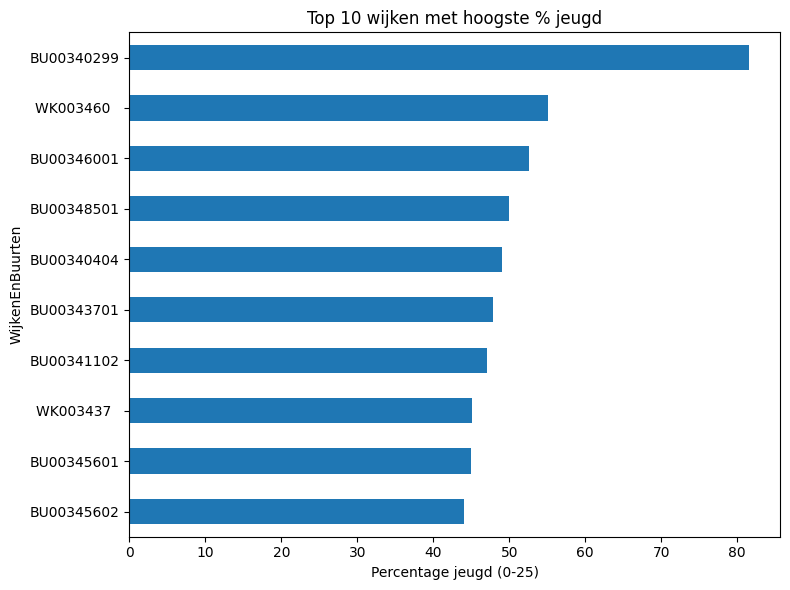

In [ ]:
import matplotlib.pyplot as plt

top10 = gemiddeld.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")

plt.title("Top 10 wijken met hoogste % jeugd")
plt.xlabel("Percentage jeugd (0-25)")
plt.tight_layout()
plt.show()

In [ ]:
# Alleen rijen waarvan de code begint met "WK"
df_wijk = df[df["Codering_3"].str.startswith("WK")]

In [ ]:
gemiddeld_wijk = df_wijk.groupby("WijkenEnBuurten")["Perc_TotaleJeugd"].mean()
print(gemiddeld_wijk.sort_values(ascending=False))

WijkenEnBuurten
WK003460      55.087411
WK003437      45.053763
WK003411      41.725905
WK003476      41.216985
WK003465      40.674168
WK003456      39.393939
WK003435      37.777778
WK003463      37.322130
WK003431      35.801503
WK003452      35.223999
WK003442      34.672609
WK003462      34.316535
WK003451      32.949050
WK003430      32.816094
WK003419      32.420530
WK003424      32.269223
WK003449      32.075936
WK003443      31.571050
WK003403      31.527597
WK003423      31.419752
WK003444      31.407843
WK003410      31.212371
WK003425      31.182503
WK003427      31.096324
WK003404      30.078703
WK003453      29.883968
WK003446      29.715640
WK003418      29.578758
WK003402      29.565205
WK003420      29.426165
WK003447      29.408708
WK003406      29.392330
WK003445      29.156355
WK003458      29.119598
WK003450      28.931786
WK003408      28.850332
WK003477      28.814918
WK003466      28.712772
WK003426      28.700378
WK003405      28.648326
WK003461      28.621858


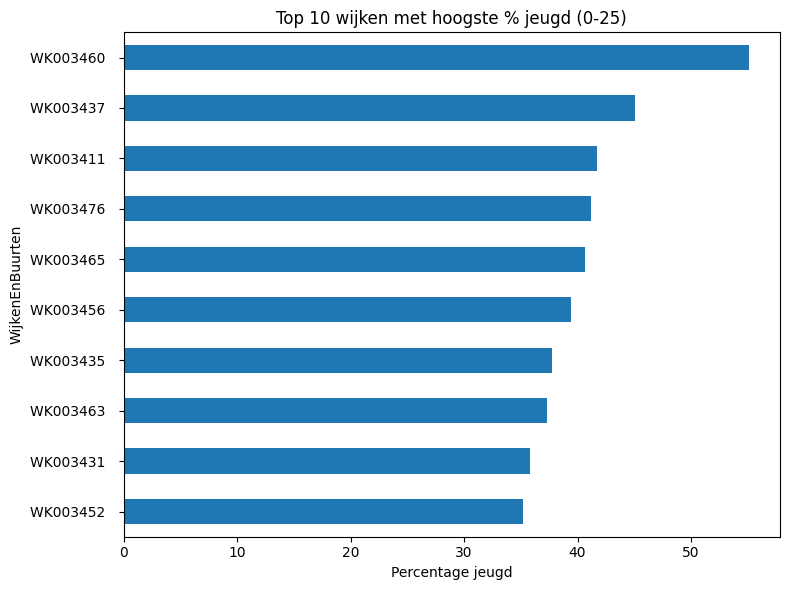

In [ ]:
import matplotlib.pyplot as plt

top10 = gemiddeld_wijk.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top10.sort_values().plot(kind="barh")

plt.title("Top 10 wijken met hoogste % jeugd (0-25)")
plt.xlabel("Percentage jeugd")
plt.tight_layout()
plt.show()

In [ ]:
# describe nu voor alleen WK-rijen
df_wijk[["Perc_TotaleJeugd"]].describe()

,Perc_TotaleJeugd
count,236.000000
mean,30.720324
std,6.730680
min,10.416667
25%,27.810195
50%,29.788587
75%,32.772947
max,85.714286
